# TỔNG QUAN VỀ DATA PROCESS

Bộ dữ liệu CIC-IDS-2017 này nhằm phục vụ việc hệ thống IDS.  

Nội dung: Làm sạch dữ liệu, tiền xử lý, tối ưu dữ liệu và  gộp dữ liệu thành dữ liệu chung trước khi vào bước huấn luyện
### Tính năng notebook:
1. **Làm sạch Dữ liệu (Data Cleaning):**:
- Xử lý các giá trị bị thiếu bằng cách loại bỏ hoặc gán giá trị thay thế (imputation).
- Loại bỏ các dữ liệu trùng lặp và sửa chữa các điểm không nhất quán để duy trì chất lượng dữ liệu.
  
2. **Phân tích Khám phá Dữ liệu (EDA)**:  
- Trực quan hóa và phân tích bộ dữ liệu để nhận diện các mẫu, điểm ngoại lai và các mối tương quan.


3. **Đánh giá Tầm quan trọng của Đặc trưng (Feature Importance Evaluation):**:
 - Đánh giá tỉ lệ quan trọng của các đặc trưng bằng kiểm định thống kê và thuật toán Random Forest.


4. **Chuẩn bị dữ liệu cho huấn luyện**:  
- Save a **cleaned dataset** for baseline model training.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

from scipy import stats
print('done')

done


# Hàm hỗ trợ khám phá dữ liệu

Các hàm hỗ trợ dùng để tối ưu khám phá sâu hơn với chi tiết dữ liệu như sau:




## Cell 1 – getFeat_type

Tác dụng:
Cell này định nghĩa một hàm dùng để phân loại các cột trong DataFrame thành hai nhóm chính: feature dạng số (numeric) và feature dạng phân loại/chuỗi (categorical). Đồng thời, cột nhãn (ví dụ Attack Type) được loại khỏi danh sách feature để tránh bị sử dụng nhầm trong các bước phân tích hoặc huấn luyện mô hình.

Ý nghĩa trong CICIDS2017:
Việc tách rõ loại feature giúp các bước EDA và xử lý sau đó (correlation, kiểm định thống kê, feature importance) được thực hiện đúng trên các cột phù hợp, tránh lỗi và giảm rủi ro data leakage.

In [2]:
def getFeat_type(df, target_col='Attack Type'):

    num_feat = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col != target_col]
    cate_feat = [col for col in df.select_dtypes(include=['object']).columns 
                 if col != target_col]

    return num_feat, cate_feat

## Cell 2 – corre_anlysis

Tác dụng:
Cell này xây dựng hàm tính ma trận tương quan (correlation matrix) giữa các feature numeric, trực quan hóa bằng heatmap, và liệt kê các cặp feature có tương quan cao vượt ngưỡng định sẵn (ví dụ 0.85).

Ý nghĩa trong CICIDS2017:
Dữ liệu lưu lượng mạng có nhiều feature được sinh ra từ cùng một luồng (flow), dẫn đến tương quan rất cao. Cell này giúp phát hiện các feature trùng thông tin (redundant) để cân nhắc loại bỏ, từ đó giảm chiều dữ liệu và giúp mô hình học hiệu quả hơn.

In [3]:
def corre_anlysis(df, num_feat, threshold=0.85):
    corr_matrix = df[num_feat].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    high_corr = [
        (corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
        for i, j in zip(*np.where((np.abs(corr_matrix) > threshold) & mask))
    ]

    return high_corr

## Cell 3 – analyze_variance_homogeneity

Tác dụng:
Cell này định nghĩa hàm kiểm tra độ đồng nhất phương sai giữa các lớp cho từng feature numeric bằng Levene’s test. Kết quả trả về statistic và p-value cho từng feature.

Ý nghĩa trong CICIDS2017:
Do dữ liệu mạng thường có nhiều outlier và phân phối lệch, phương sai giữa các lớp (Benign vs Attack) thường không đồng nhất. Cell này giúp đánh giá đặc điểm phân bố của feature và hỗ trợ quyết định sử dụng kiểm định phi tham số hoặc các biến đổi dữ liệu phù hợp.

In [4]:
# 3. Variance analysis (df, num_feat, target_col='Attack Type') – Levene -> dict with results
def analyze_variance_homogeneity(df, num_feat, target_col='Attack Type'):  
    results_levene = {}  
    grouped = df.groupby(target_col)
    
    for feature in num_feat:  
        groups = [
            group[feature].dropna().values 
            for name, group in grouped
            if len(group[feature].dropna()) > 0 
            and np.var(group[feature].dropna()) > 0
            and np.any(group[feature].dropna() != 0)
        ]
        
        if len(groups) < 2:  
            print(f"Not enough valid groups to perform Levene's test for feature: {feature}")  
            continue
        
        stat_levene, p_value_levene = stats.levene(*groups)  
        results_levene[feature] = {'Statistic': stat_levene, 'p-value': p_value_levene}  

    return results_levene

## Cell 4 – analyze_feature_importance (Kruskal–Wallis)

Tác dụng:
Cell này tạo hàm đánh giá khả năng phân biệt lớp của từng feature numeric bằng Kruskal–Wallis test, một kiểm định phi tham số. Hàm trả về thống kê H và p-value, đồng thời sắp xếp và trực quan hóa các feature theo mức độ quan trọng thống kê.

Ý nghĩa trong CICIDS2017:
Vì dữ liệu không tuân theo phân phối chuẩn và chứa nhiều outlier, Kruskal–Wallis phù hợp hơn ANOVA. Cell này giúp xác định các feature có giá trị phân tách lớp tốt trước khi đưa vào huấn luyện mô hình.

In [5]:
# 4. Feature importance analysis (df, num_feat, target_col='Attack Type') – Kruskal-Wallis -> df with H-statistics and p-values
def analyze_feature_importance(df, num_feat, target_col='Attack Type'): 

    h_scores = {}  
    
    for feature in num_feat:  
        # Group data by y and perform the Kruskal-Wallis test  
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)]  
        h_stat, p_val = stats.kruskal(*groups)  
        h_scores[feature] = {'H-statistic': h_stat, 'p-value': p_val}  

    # Create a DataFrame from the results  
    h_scores_df = pd.DataFrame.from_dict(h_scores, orient='index')  
    h_scores_df = h_scores_df.sort_values('H-statistic', ascending=False)  

    # Plotting H-statistics  
    plt.figure(figsize=(18, 10))  
    plt.bar(range(len(h_scores_df)), h_scores_df['H-statistic'], color='skyblue')  
    plt.xticks(range(len(h_scores_df)), h_scores_df.index, rotation=90)  
    plt.title('Feature Importance based on H-statistic (Kruskal-Wallis Test)')  
    plt.xlabel('Features')  
    plt.ylabel('H-statistic')  
    plt.tight_layout()  
    plt.show()  

    return h_scores_df

## Cell 5 – analyze_feature_importance_rf

Tác dụng:
Cell này định nghĩa hàm huấn luyện thử một Random Forest Classifier để:

Đánh giá feature importance theo mô hình

Tính confusion matrix, classification report

Thực hiện cross-validation để kiểm tra độ ổn định

Ý nghĩa trong CICIDS2017:
Random Forest hoạt động tốt với dữ liệu nhiều chiều và không tuyến tính như CICIDS2017. Cell này cung cấp một góc nhìn theo mô hình học máy về mức độ quan trọng của feature, bổ sung cho các phương pháp thống kê truyền thống.

In [6]:
# 5. Feature importance analysis(df, num_feat, target_col='Attack Type') – Tree Model -> df with features ordered by importance; confusion matrix; labels; cv_scores
def analyze_feature_importance_rf(df, num_feat, target_col='Attack Type'):
    """
    Analyze feature importance using a Random Forest classifier.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset
    num_feat : list
        List of column names containing numerical features to analyze
    target_col : str
        Column name of the target variable

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing feature importances sorted by importance in descending order
    cm
        Confusion Matrix for further analysis
    rf_labels
        Labels for plotting the confusion matrix
    cv_scores
        Cross-validation scores for future reference

    Notes:
    ------
    - Uses a Random Forest classifier to assess feature importance.
    - Generates bar plot of feature importances for visual comparison.
    """

    # Hyperparameter settings - OPTIMIZED for speed
    hyperparameters = {
        'n_estimators': 100,     # 150 → 100 (balance speed vs accuracy)
        'max_depth': 20,         # 30 → 20 (faster, still good)
        'min_samples_split': 5,  # Prevent overfitting
        'random_state': 42,
        'n_jobs': -1
    }

    # Prepare the data
    X = df[num_feat]
    y = df[target_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=hyperparameters['random_state'], stratify=y)

    # Create the Random Forest model with specified hyperparameters
    rf = RandomForestClassifier(**hyperparameters)

    # Fit the model on the training set
    rf.fit(X_train, y_train)

    # Cross-validation on the training set - reduced folds for speed
    cv_scores = cross_val_score(rf, X_train, y_train, cv=3, n_jobs=-1)
    print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
    
    # Predict on test set
    y_pred = rf.predict(X_test)

    # Feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': num_feat, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # Confusion matrix
    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)

    # Calculate test scores
    report = classification_report(y_test, y_pred, target_names=rf_labels)
    print("\nClassification Report:\n")
    print(report, end='\n\n')

    # Plot feature importances
    plt.figure(figsize=(18, 12))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.title('Feature Importance from Random Forest')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return feature_importance_df, cm, rf_labels, cv_scores

## Cell 6 – calculate_outliers_percentage

Tác dụng:
Cell này xây dựng hàm tính tỉ lệ outlier (%) của từng feature dựa trên quy tắc IQR (Interquartile Range). Kết quả cho biết feature nào chứa nhiều giá trị bất thường.

Ý nghĩa trong CICIDS2017:
Nhiều feature mạng (rate, bytes, packets) có outlier rất lớn do burst traffic hoặc attack behavior. Cell này giúp nhận diện các feature “khó học” để cân nhắc áp dụng log-transform, robust scaling, clipping, hoặc loại bỏ nếu cần thiết.

In [7]:
# 6. Calculation of the percentage of outliers for each feature (df) – IQR -> dict with outliers percentage
def calculate_outliers_percentage(df):

    outlierPercent = {}  # empty dictionary to store outlier percentages

    for column in df.columns:
        Q1 = df[column].quantile(0.25)  # first quartile (Q1) for the column
        Q3 = df[column].quantile(0.75)  # third quartile (Q3) for the column
        IQR = Q3 - Q1  # Interquartile Range (IQR)

        lower_bound = Q1 - 1.5 * IQR  # lower bound for outliers
        upper_bound = Q3 + 1.5 * IQR  # upper bound for outliers

        # Identify outliers in the column
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Calculate the percentage of outliers for the column
        outlier_percentage = len(outliers) / len(df) * 100

        # Store the outlier percentage in the dictionary
        outlierPercent[column] = outlier_percentage

    return outlierPercent

# 6. Calculation of the percentage of outliers for each feature (df) – IQR -> dict with outliers percentage
def calculate_outliers_percentage(df):
    outlierPercent = {}
    
    # Calculate quantiles for all columns at once
    quartiles = df.quantile([0.25, 0.75])
    total_rows = len(df)
    
    for column in df.columns:
        # Extract Q1 and Q3 from pre-calculated quartiles
        Q1 = quartiles.loc[0.25, column]
        Q3 = quartiles.loc[0.75, column]
        IQR = Q3 - Q1
        
        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Create boolean mask for outliers
        is_outlier = (df[column] < lower_bound) | (df[column] > upper_bound)
        
        # Count and calculate percentage
        outlier_percentage = (is_outlier.sum() / total_rows) * 100
        
        outlierPercent[column] = outlier_percentage

    return outlierPercent

# 1. Khám phá dữ liệu sơ bộ toàn cục
Load dataset và kiểm tra các thuộc tính (kích thước, kiểu dữ liệu, các giá trị bị thiếu)

## 1.1. Nạp dữ liệu đầu vào

In [8]:
dfs = []
read_csv = pd.read_csv
join = os.path.join

read_kwargs = {}
try:
    pass
    # read_kwargs["engine"] = "pyarrow" # Fixed TimeoutError
except Exception:
    pass

for dirname, _, filenames in os.walk('Input/'):
    paths = (join(dirname, filename) for filename in filenames if filename.lower().endswith(".csv"))
    for filename in paths: 
        dfs.append(read_csv(filename, **read_kwargs))
        print('done')


done
done
done
done
done
done
done
done


In [9]:
out = []
for i, data in enumerate(dfs, start=1):
    rows, cols = data.shape
    out.append(f'df{i} -> {rows} rows, {cols} columns')
print('\n'.join(out))



df1 -> 288602 rows, 79 columns
df2 -> 529918 rows, 79 columns
df3 -> 191033 rows, 79 columns
df4 -> 286467 rows, 79 columns
df5 -> 225745 rows, 79 columns
df6 -> 445909 rows, 79 columns
df7 -> 692703 rows, 79 columns
df8 -> 170366 rows, 79 columns


## 1.2. Gộp dataframe

CICISD2017 nhằm phục vụ hệ thống phát hiện xâm nhập (IDS) với nhiều loại tấn công khác nhau. Nó được chia làm nhiều tập nên gộp lại để huấn luyẹn phục vụ model

In [10]:
data = pd.concat(dfs, axis=0, ignore_index=True)
for df in dfs: del df 
print('done')

done


## 1.3. Tổng quan về dữ liệu

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [12]:
print(f"Dataset Dimensions: {data.shape}")

Dataset Dimensions: (2830743, 79)


In [13]:
data.head(4)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [14]:

data.sample(n=6, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,53,30767,2,2,70,102,35,35,35.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,48461,2,2,76,200,38,38,38.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,80,1,2,0,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk
699389,53,191,2,2,74,138,37,37,37.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,2126,33,1,1,0,6,0,0,0.0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
800686,44761,52,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
mis_val = data.isna().sum()
mis_percent = (mis_val / len(data)) * 100

out = []
for column, count in mis_val.items():
    if count != 0:
        out.append(
            f"Cols '{column}' has {count} missing values, include {mis_percent[column]:.2f}% of the total"
        )

print("\n".join(out))


Cols 'Flow Bytes/s' has 1358 missing values, include 0.05% of the total


# 2. Lmaf sạch bộ dữ liệu

In [16]:
# làm sạch tên cột: xóa khoảng trắng ở đầu/cuối mỗi cột
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

## 2.1. Dữ liệu trùng lặp và giá trị vô cực

In [17]:
duplicates = data.duplicated()
duplicate_count = duplicates.sum()
print(f"Giá trị trùng lặp: {duplicate_count}")

Giá trị trùng lặp: 308381


In [18]:
# Loại bỏ trùng lặp
data = data.drop_duplicates(keep='first')
del duplicates
data.shape


(2522362, 79)

In [19]:
# Làm sạch dữ liệu
# Xóa khoảng trắng thừa để chuẩn hóa tên
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)
# Xóa các cột bị trùng tên 
data = data.loc[:, ~data.columns.duplicated()]
print("Kích thước sau khi xử lý:", data.shape)

Kích thước sau khi xử lý: (2522362, 79)


In [20]:
ident_cols = {}
columns = data.columns
list_control = columns.copy().tolist()

for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in ident_cols) and (col1 in list_control):
                    ident_cols[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in ident_cols) and (col1 in list_control):
                    ident_cols[col1].append(col2)
                    list_control.remove(col2)
if ('Fwd Header Length.1' in columns) and ('Fwd Header Length' in columns):
    if data['Fwd Header Length'].equals(data['Fwd Header Length.1']):
        if 'Fwd Header Length' not in ident_cols:
            ident_cols['Fwd Header Length'] = ['Fwd Header Length.1']
        else:
            if 'Fwd Header Length.1' not in ident_cols['Fwd Header Length']:
                ident_cols['Fwd Header Length'].append('Fwd Header Length.1')

        for key, value in ident_cols.items():
            if key != 'Fwd Header Length' and 'Fwd Header Length.1' in value:
                value.remove('Fwd Header Length.1')


if ident_cols:
    print("Identical columns found:")
    for key, value in ident_cols.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

Identical columns found:
'Total Fwd Packets' is identical to ['Subflow Fwd Packets']
'Total Backward Packets' is identical to ['Subflow Bwd Packets']
'Fwd PSH Flags' is identical to ['SYN Flag Count']
'Bwd PSH Flags' is identical to ['Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
'Fwd URG Flags' is identical to ['CWE Flag Count']
'Fwd Header Length' is identical to ['Fwd Header Length.1']


In [21]:
for key, value in ident_cols.items():
    data.drop(columns=value, inplace=True)

In [22]:
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [23]:
numCols = data.select_dtypes(include = np.number).columns
has_infinite = np.isinf(data[numCols]).sum()
print(has_infinite[has_infinite > 0])

Flow Bytes/s      1211
Flow Packets/s    1564
dtype: int64


In [24]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

## 2.1. Missing Values


In [25]:

att_count = data['Label'].value_counts().reset_index()
att_count.columns = ['Attack Type', 'Number of Occurrences']

occur_nonnull = data.dropna()['Label'].value_counts().reset_index()
occur_nonnull.columns = ['Attack Type', 'Occurrences w/o Null Rows']
att_count = att_count.merge(occur_nonnull, on='Attack Type', how='left')

att_count = att_count.assign(
    **{'Abs Difference': lambda x: x['Number of Occurrences'] - x['Occurrences w/o Null Rows'],
       'Difference %': lambda x: ((x['Number of Occurrences'] - x['Occurrences w/o Null Rows']) / x['Number of Occurrences'] * 100).round(2)}
)

att_count


,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


In [26]:
threshold = 10
mis_percent = data.isnull().mean() * 100

high_missing_cols = mis_percent[mis_percent > threshold]

print(f'The following columns have over {threshold}% of missing values:' if not high_missing_cols.empty 
      else 'Không có cột với miss values vượt ngưỡng')

if not high_missing_cols.empty:
    print(high_missing_cols)

Không có cột với miss values vượt ngưỡng


In [27]:
rowMis_percnett = data.isna().mean(axis=1) * 100
missing_rows = data.isna().any(axis=1).sum()

print(rowMis_percnett.describe())
print(f'\nTotal rows with missing values: {missing_rows}')

count    2.522362e+06
mean     1.850907e-03
std      7.430795e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.985075e+00
dtype: float64

Total rows with missing values: 1564


In [28]:

data = data.dropna()
print(f'Dataset shape after row-wise removal: {data.shape}')

Dataset shape after row-wise removal: (2520798, 67)


## 2.2. DataD riven Feature Selection Impact



In [29]:

unique_column = [col for col in data.columns if data[col].nunique() == 1]
if unique_column:
    print('\n'.join(unique_column))
    
print(f'\nThe number of columns with only one unique values is: {len(unique_column)}')

Bwd PSH Flags

The number of columns with only one unique values is: 1


In [30]:

data.drop(unique_column, axis=1, inplace=True)
del unique_column

In [31]:

data.shape

(2520798, 66)

## 2.3. Grouping/ Removing Attack Types


### 2.3.1. Grouping attack types

Bảng danh sách các lưu lượng trong bộ dữ liệu - nguồn trang chính của bộ dữ liệu


| **Group**                     | **Attack Type**             | **Count**  |  
|-------------------------------|-----------------------------|------------|  
| **Normal Traffic**            | BENIGN                      | 2,095,057  |  
|                               |                             | **Total: 2,095,057** |  
| **DoS Attacks**              | DoS Hulk                   | 172,846    |  
|                               | DoS GoldenEye               | 10,286     |  
|                               | DoS Slowloris               | 5,385      |  
|                               | DoS Slowhttptest            | 5,228      |
|                               |                             | **Total: 193,745** |
| **DDoS Attacks**              | DDoS                        | 128,014     |
|                               |                             | **Total: 128,014** |
| **Port Scanning**            | PortScan                    | 90,694     |  
|                               |                             | **Total: 90,694**  |  
| **Brute Force Attacks**      | FTP-Patator                 | 5,931      |  
|                               | SSH-Patator                 | 3,219      |  
|                               |                             | **Total: 9,150**   |  
| **Bots**                      | Bot                         | 1,948      |  
|                               |                             | **Total: 1,948**   |  
| **Web Attacks**              | Web Attack – Brute Force    | 1,470      |  
|                               | Web Attack – XSS            | 652        |  
|                               | Web Attack – SQL Injection   | 21         |  
|                               |                             | **Total: 2,143**   |  
| **Infiltration Attacks**     | Infiltration                | 36         |  
|                               |                             | **Total: 36**      |  
| **Miscellaneous**            | Heartbleed                  | 11         |  
|                               |                             | **Total: 11**      |

In [32]:

group_mapping = {
    'BENIGN': 'Normal Traffic',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'Port Scanning',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Bot': 'Bots',
    'Web Attack � Brute Force': 'Web Attacks',
    'Web Attack � XSS': 'Web Attacks',
    'Web Attack � Sql Injection': 'Web Attacks',
    'Heartbleed': 'Miscellaneous'
}

data['Attack Type'] = data['Label'].replace(group_mapping)
data['Attack Type'].value_counts()

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Infiltration           36
Miscellaneous          11
Name: count, dtype: int64

In [33]:
# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

In [34]:

data = data[~data['Attack Type'].isin(['Infiltration', 'Miscellaneous'])]

In [35]:

print(f'Dataset shape: {data.shape}')
print(f'\nAttack type distribution:')
print(data['Attack Type'].value_counts())

Dataset shape: (2520751, 66)

Attack type distribution:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


# 3. Exploratory Data Analysis (EDA)

## 3.1. Descriptive Statistics

In [36]:
data.sample(5)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
1212573,1840,64,1,1,0,6,0,0,0.000000,0.000000,...,40,0.0,0.0000,0,0,0.0,0.0000,0,0,Port Scanning
2478968,443,12886,3,0,83,0,46,6,27.666667,20.207259,...,20,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic
435086,443,8087529,6,4,586,221,517,0,97.666667,206.283947,...,20,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic
2787030,443,117428690,12,10,891,402,517,0,74.250000,146.522803,...,20,431667.0,486338.1446,775560,87774,58200000.0,328525.3461,58500000,58000000,Normal Traffic
2515092,44322,58,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0000,0,0,0.0,0.0000,0,0,Normal Traffic


In [37]:
data.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,...,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06
mean,8.690744e+03,1.659032e+07,1.025880e+01,1.155289e+01,6.065243e+02,1.811292e+04,2.311993e+02,1.920377e+01,6.350189e+01,7.732029e+01,...,5.997266e+00,-3.082291e+03,9.152230e+04,4.616835e+04,1.719410e+05,6.542438e+04,9.337159e+06,5.656738e+05,9.763454e+06,8.892545e+06
std,1.901294e+04,3.523140e+07,7.943824e+02,1.056905e+03,1.011595e+04,2.398149e+06,7.563122e+02,6.079887e+01,1.955512e+02,2.968824e+02,...,6.743909e+02,1.149769e+06,6.858746e+05,4.161453e+05,1.084664e+06,6.106447e+05,2.484810e+07,4.873871e+06,2.561725e+07,2.458139e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.000000e+00,1.200000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062000e+04,2.000000e+00,2.000000e+00,6.600000e+01,1.560000e+02,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.332968e+06,6.000000e+00,5.000000e+00,3.320000e+02,9.970000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,...,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


## 3.2. Correlation Analysis


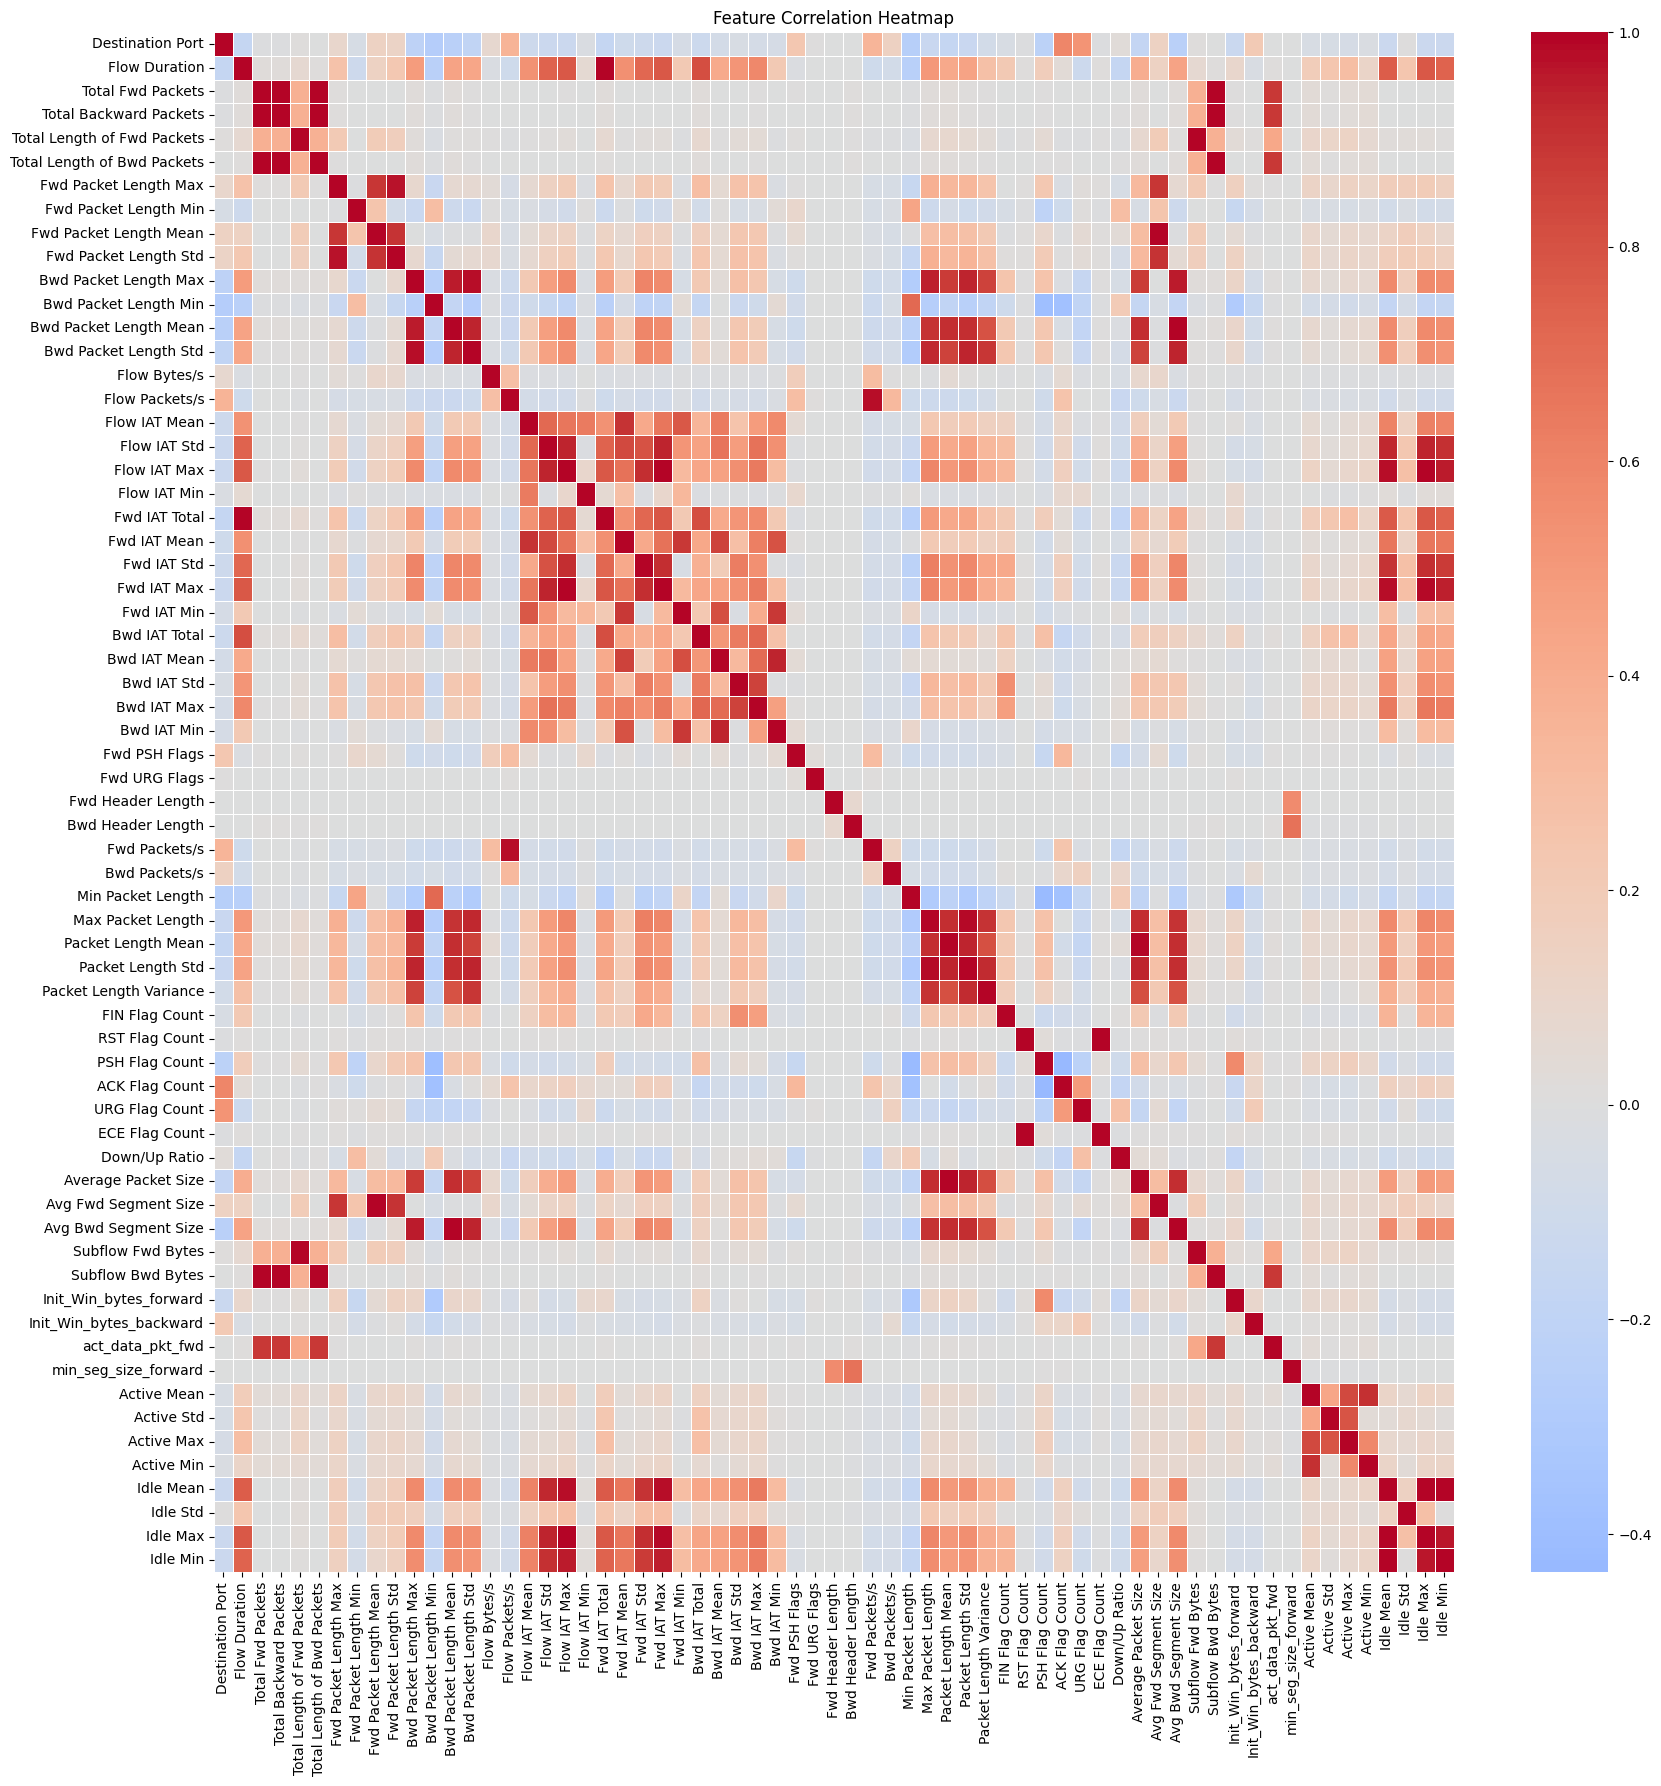

In [38]:
num_feat, cate_feat = getFeat_type(data)
high_corr = corre_anlysis(data, num_feat) 

In [39]:

for item in high_corr:
    print(f'{item[0]} has a high correlation with {item[1]}: {item[2]:.4f}')

high_multicollinearity = [item for item in high_corr if item[2] >= 0.95]

Flow Duration has a high correlation with Fwd IAT Total: 0.9985
Total Fwd Packets has a high correlation with Total Backward Packets: 0.9991
Total Fwd Packets has a high correlation with Total Length of Bwd Packets: 0.9970
Total Fwd Packets has a high correlation with Subflow Bwd Bytes: 0.9970
Total Fwd Packets has a high correlation with act_data_pkt_fwd: 0.8874
Total Backward Packets has a high correlation with Total Length of Bwd Packets: 0.9945
Total Backward Packets has a high correlation with Subflow Bwd Bytes: 0.9944
Total Backward Packets has a high correlation with act_data_pkt_fwd: 0.8826
Total Length of Fwd Packets has a high correlation with Subflow Fwd Bytes: 1.0000
Total Length of Bwd Packets has a high correlation with Subflow Bwd Bytes: 1.0000
Total Length of Bwd Packets has a high correlation with act_data_pkt_fwd: 0.8840
Fwd Packet Length Max has a high correlation with Fwd Packet Length Mean: 0.8890
Fwd Packet Length Max has a high correlation with Fwd Packet Length 

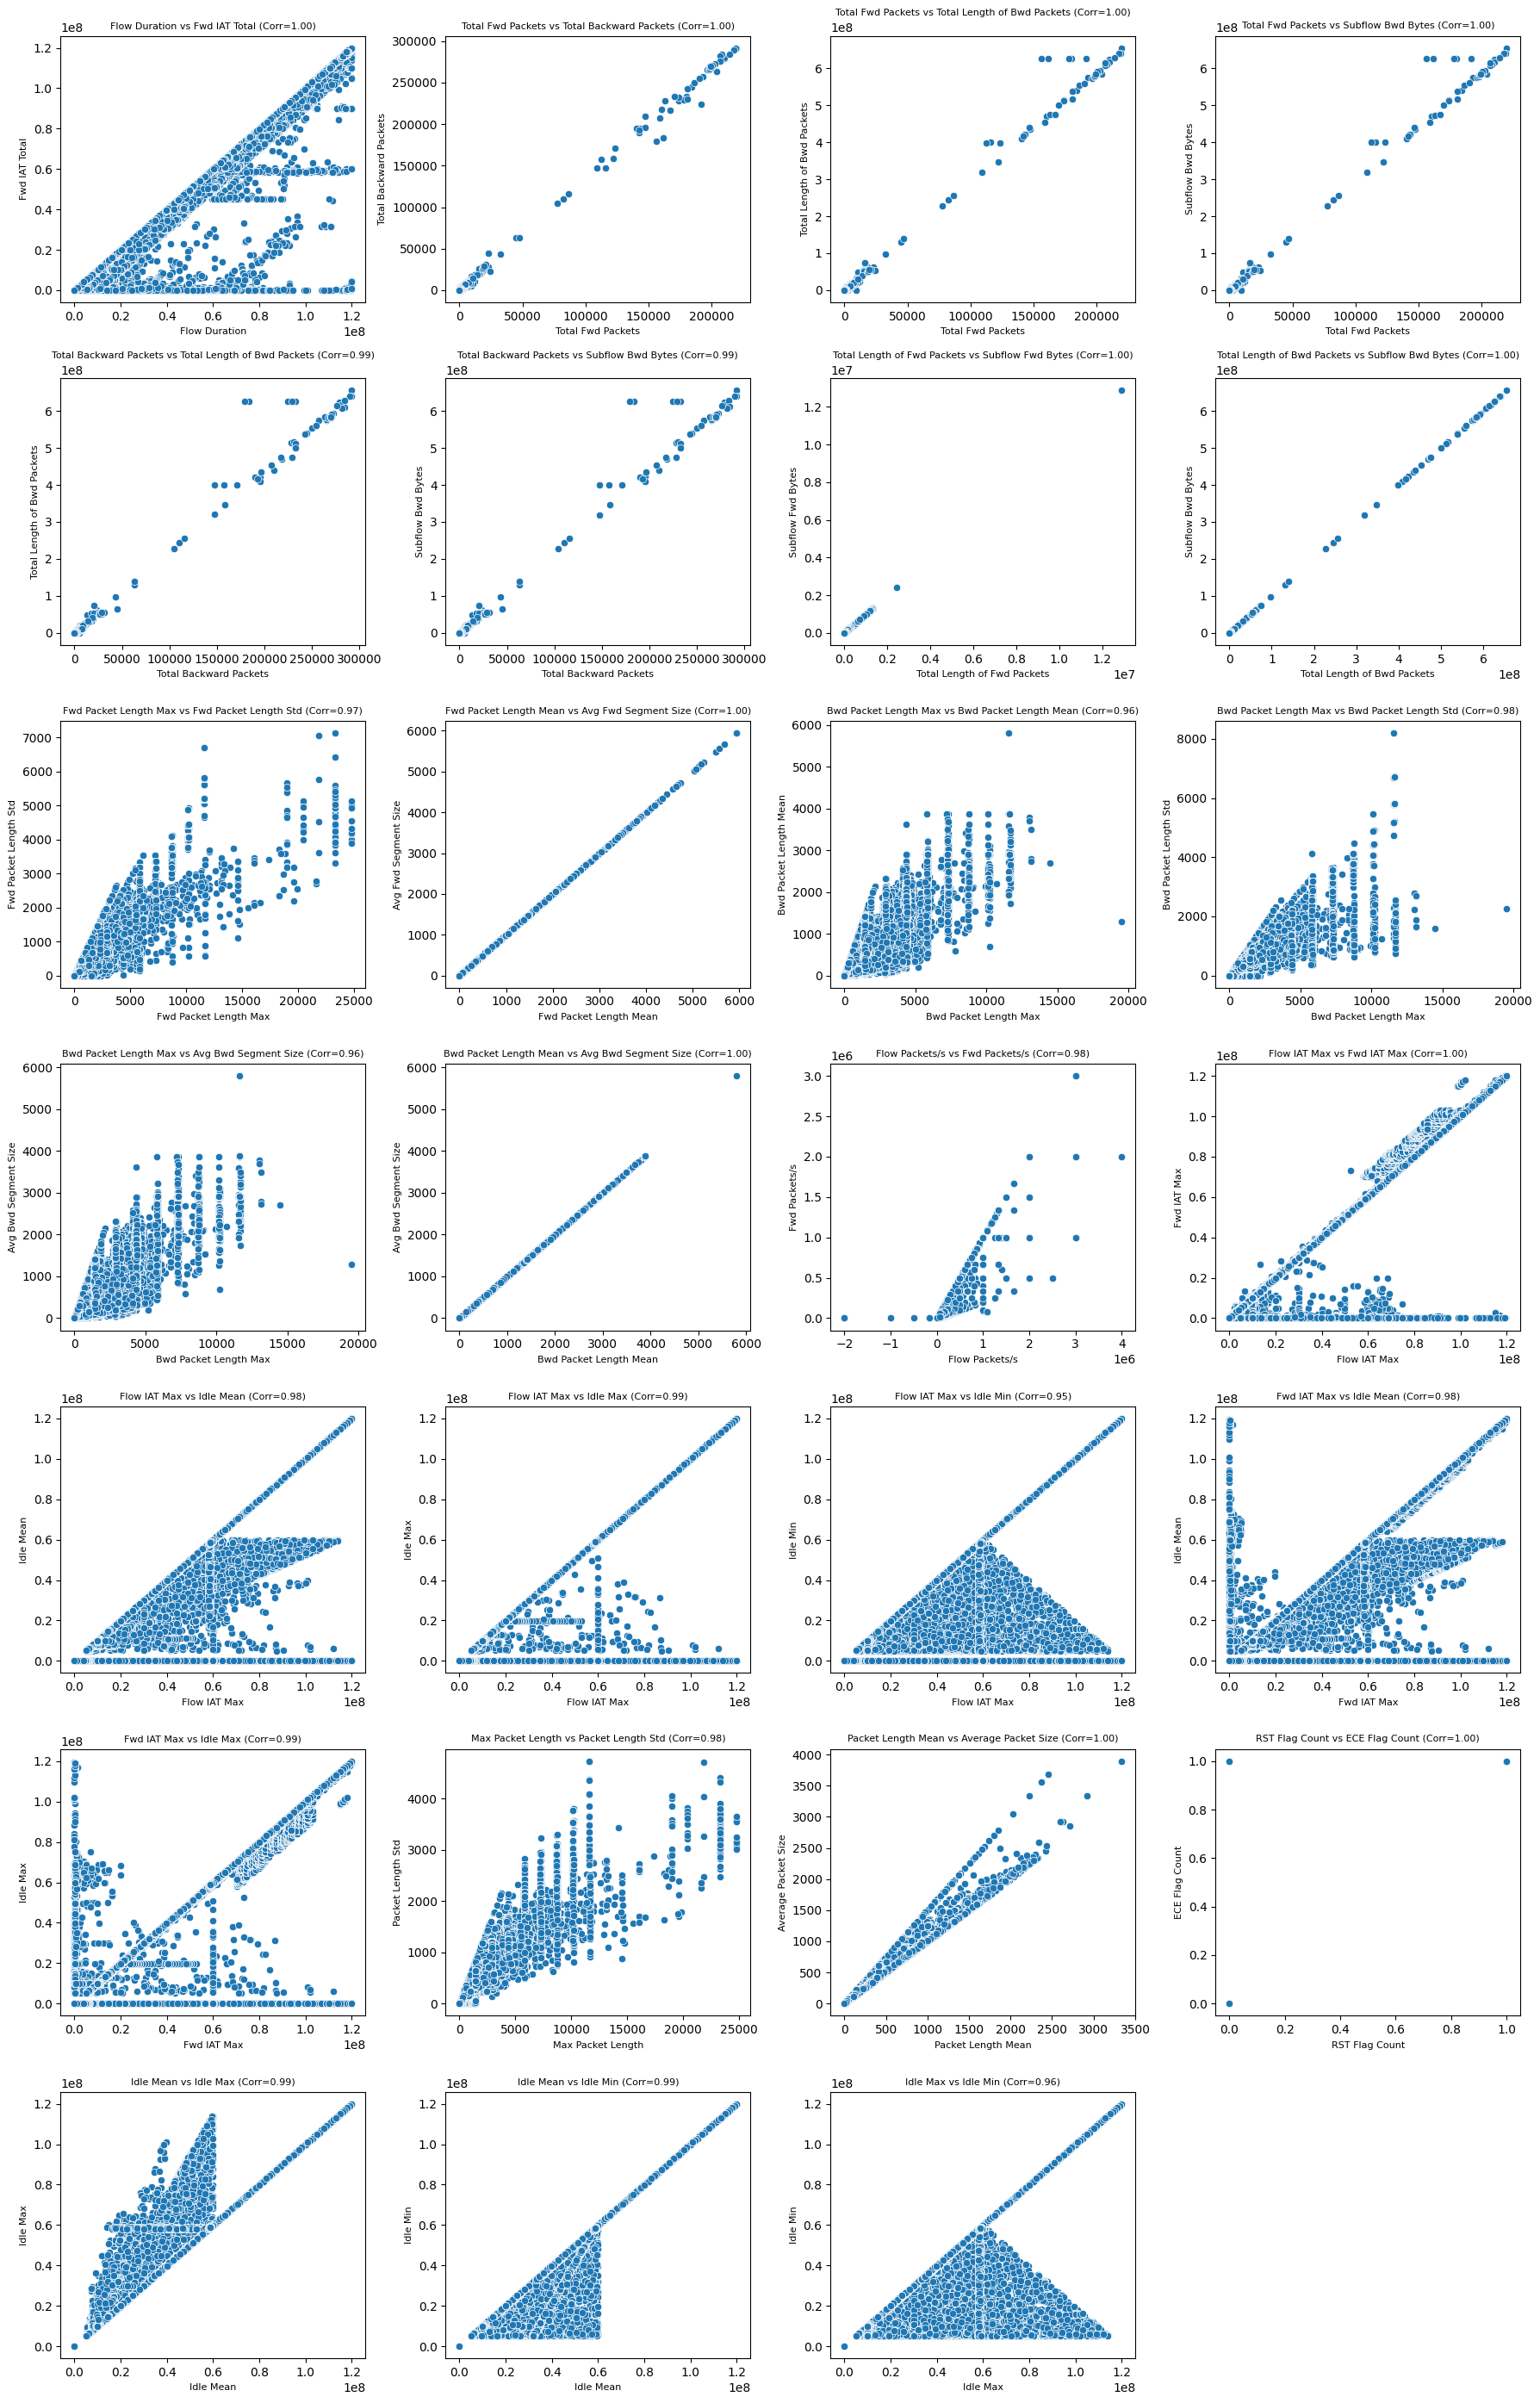

In [40]:

n_plots = len(high_multicollinearity)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, (feat_x, feat_y, corr_val) in enumerate(high_multicollinearity):
    sns.scatterplot(x=data[feat_x], y=data[feat_y], ax=axes[i])
    axes[i].set_title(f'{feat_x} vs {feat_y} (Corr={corr_val:.2f})', fontsize=8)
    axes[i].set_xlabel(feat_x, fontsize=8)
    axes[i].set_ylabel(feat_y, fontsize=8)

for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

By evaluating the plots, we can identify some features with perfect/near-perfect linear correlation. Removing one instance can reduce redundancy and mitigate potential issues with multicollinearity in future models

In [41]:
select_cols = ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']

select_cols = [col for col in select_cols if col in data.columns]

if select_cols:
    print(f'Dropping {len(select_cols)} columns: {select_cols}')
    data.drop(columns=select_cols, inplace=True)
else:
    print('No columns to drop (already removed)')
num_feat, cate_feat = getFeat_type(data)
data.shape


Dropping 5 columns: ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']


(2520751, 61)

## 3.3. Outliers

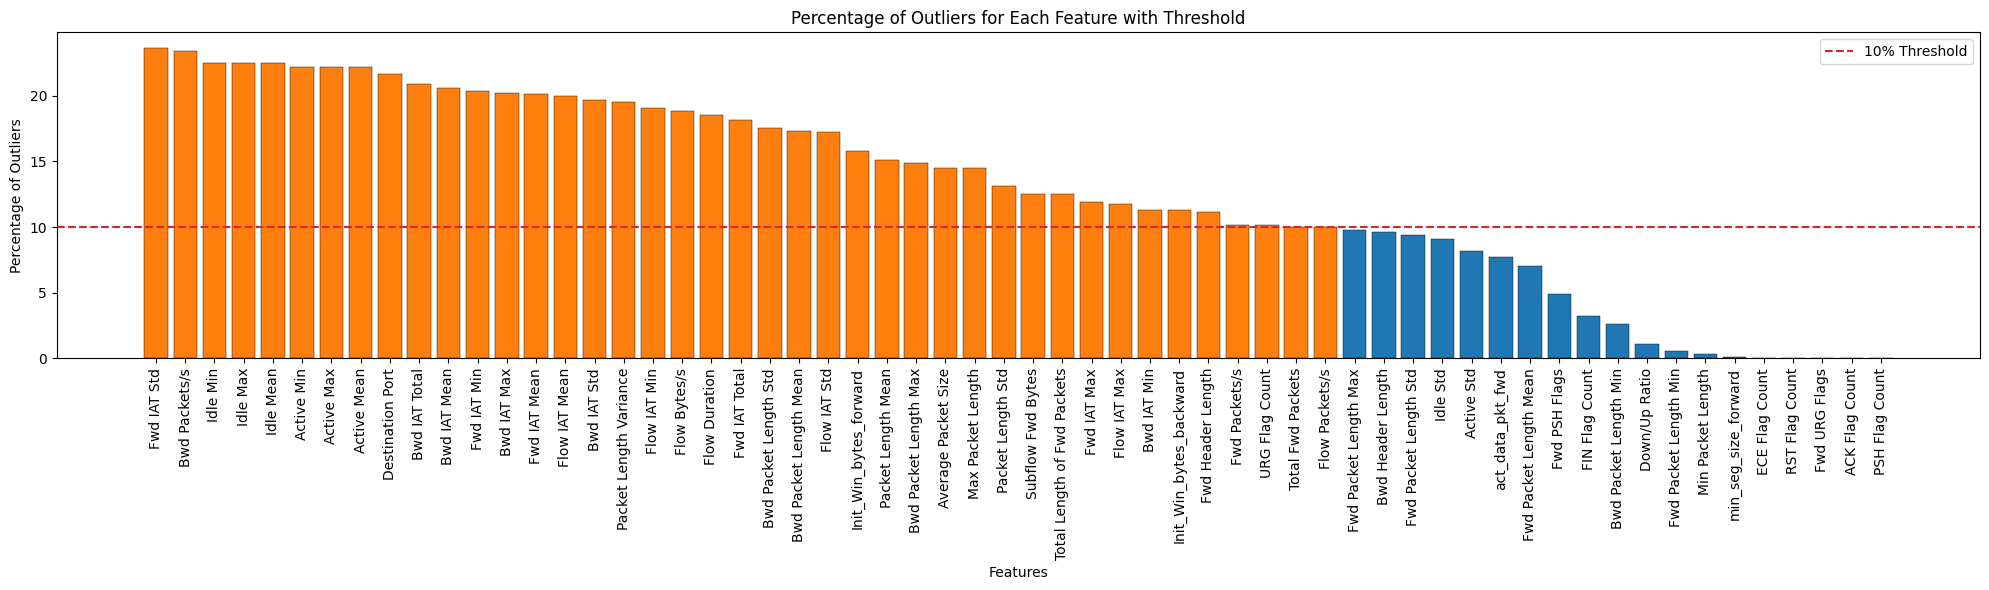

Features with outlier percentage above 10%:

                             Outlier_Percentage
Fwd IAT Std                           23.657989
Bwd Packets/s                         23.402391
Idle Min                              22.501508
Idle Max                              22.501508
Idle Mean                             22.501508
Active Min                            22.167917
Active Max                            22.167917
Active Mean                           22.167917
Destination Port                      21.645137
Bwd IAT Total                         20.926819
Bwd IAT Mean                          20.602908
Fwd IAT Min                           20.366311
Bwd IAT Max                           20.187555
Fwd IAT Mean                          20.126462
Flow IAT Mean                         19.985512
Bwd IAT Std                           19.700319
Packet Length Variance                19.538899
Flow IAT Min                          19.072649
Flow Bytes/s                          18.84

In [42]:
#% outliers
outlierPercent = calculate_outliers_percentage(data[num_feat])
outliers_df = pd.DataFrame.from_dict(outlierPercent, orient='index', columns=['Outlier_Percentage'])
threshold = 10
high_outlier_features = outliers_df[outliers_df['Outlier_Percentage'] > threshold]
outliers_df_sorted = outliers_df.sort_values(by='Outlier_Percentage', ascending=False)

fig, ax = plt.subplots(figsize=(20, 6))

colors = np.where(outliers_df_sorted['Outlier_Percentage'].values > threshold, "#ff7f0e", "#1f77b4")
ax.bar(outliers_df_sorted.index, outliers_df_sorted['Outlier_Percentage'].values,
       color=colors, edgecolor="black", linewidth=0.3)
ax.axhline(y=threshold, color="#d62728", linestyle='--', linewidth=1.5, label=f'{threshold}% Threshold')
ax.set_xlabel('Features')
ax.set_ylabel('Percentage of Outliers')
ax.set_title('Percentage of Outliers for Each Feature with Threshold')
ax.legend()
ax.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.show()


print(f"Features with outlier percentage above {threshold}%:\n")
print(high_outlier_features.sort_values('Outlier_Percentage', ascending=False))
if 'outliers_df' in locals():
    del outliers_df


## 3.4. Data Distribution

In [43]:
norm_dist = 0
not_norm_dist = 0
norm_features = []
non_norm_features = []

for col in num_feat:
    result = stats.anderson(data[col], dist='norm')
    
    if result.statistic < result.critical_values[2]:
        norm_dist += 1
        norm_features.append(col)
    else:
        not_norm_dist += 1
        non_norm_features.append(col)

print(f'{norm_dist} features are normally distributed')
print(f'{not_norm_dist} features are not normally distributed - Reject null hypothesis')
print(f'\nPercentage: {(not_norm_dist/len(num_feat)*100):.1f}% are non-normal')

/var/folders/7z/vsmzd7593_lgbdjr7bpskkx80000gn/T/ipykernel_20892/1144483410.py:7: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(data[col], dist='norm')


0 features are normally distributed
60 features are not normally distributed - Reject null hypothesis

Percentage: 100.0% are non-normal


## 3.5. Class Imbalance

In [44]:
att_count_df = data['Attack Type'].value_counts().reset_index()
att_count_df.columns = ['Attack Type', 'Number of Occurrences']

att_count_df['% of Total'] = (att_count_df['Number of Occurrences'] / len(data) * 100).round(2)

print(att_count_df)

      Attack Type  Number of Occurrences  % of Total
0  Normal Traffic                2095057       83.11
1             DoS                 193745        7.69
2            DDoS                 128014        5.08
3   Port Scanning                  90694        3.60
4     Brute Force                   9150        0.36
5     Web Attacks                   2143        0.09
6            Bots                   1948        0.08


# Mất cân bằng lớp (Class Imbalance)
Các phân tích trước đó cho thấy sự mất cân bằng lớp rõ rệt. Điều này cần được xem xét kỹ lưỡng khi làm việc với tập dữ liệu CIC-IDS-2017, như đã được Panigrahi và Borah (2018) nhấn mạnh.

Thghu thập dữ liệu ta thấy:

Phần đông của lớp 'BENIGN' / Lưu lượng bình thường – chiếm 83,1% 

Các loại tấn công có số lượng thấp hơn - Ngay cả DoS, lớp phổ biến thứ hai, cũng có số lượng mẫu thấp.

Các lớp rất hiếm ngay cả sau khi gộp nhóm, chẳng hạn như Bots, Web Attacks (Tấn công Web) và Brute Force (Tấn công vét cạn).

Các vấn đề tồn động:

Loại mô hình (Model Bias): Các mô hình có thể bị nghiêng về phía lớp đa số (lớp bình thường), dẫn đến độ chính xác (accuracy) tổng thể cao nhưng độ phủ (recall) và độ chính xác (precision) lại kém đối với các lớp thiểu số (các loại tấn công).

Chỉ số hiệu năng: accuracy, F1-score, precision, recall, hoặc ROC-AUC  để đánh giá khả năng phân loại hiệu quả giữa các lớp.

Các idea để giải quyết vấn đề trong quá trình huấn luyện ML:

Trọng số lớp (Class weights): Áp dụng trọng số để "phạt" nặng hơn các sai sót dự đoán trên các lớp thiểu số.

Phương pháp Ensemble (Học kết hợp): Sử dụng các thuật toán như Random Forests hoặc XGBoost để cải thiện khả năng dự đoán tổng thể mô hình.

Kiểm định chéo (Cross-validation): Sử dụng các fold (phần chia) mang tính đại dieejn
SMOTE ( 1 phần): Sử dụng SMOTE để tạo thêm dữ liệu, giúp cân bằng phân phối dữ liệu.

Undersampling (Giảm mẫu): Giảm bớt số lượng mẫu của lớp đa số (BENIGN).

In [45]:
# Cleaning up
if 'att_count_df' in locals():
    del att_count_df

# 5. Feature Importance

Before conducting an analysis of feature importance, some characteristics of the dataset must be gathered. We already know it does not follow a Gaussian distribution and has a high presence of outliers. The next step is to evaluate its variance to determine the best statistical test.

In [46]:

variance_result = analyze_variance_homogeneity(data, num_feat)

Not enough valid groups to perform Levene's test for feature: Fwd URG Flags
Not enough valid groups to perform Levene's test for feature: RST Flag Count
Not enough valid groups to perform Levene's test for feature: ECE Flag Count


In [47]:

significant_features = {f: r for f, r in variance_result.items() if r['p-value'] <= 0.05}
non_significant_features = {f: r for f, r in variance_result.items() if r['p-value'] > 0.05}

total_features = len(variance_result)
significant_count = len(significant_features)
non_significant_count = len(non_significant_features)

print(f"Variance Homogeneity Analysis Summary:")
print(f"{'='*50}")
print(f"Total features analyzed: {total_features}")
print(f"Significant variance differences (p ≤ 0.05): {significant_count} ({significant_count/total_features*100:.1f}%)")
print(f"Non-significant variance differences (p > 0.05): {non_significant_count} ({non_significant_count/total_features*100:.1f}%)")

if non_significant_features:
    print(f"\n{'='*50}")
    print(f"Features with homogeneous variances (p > 0.05):")
    print(f"{'='*50}")
    
    sorted_non_sig = sorted(non_significant_features.items(), key=lambda x: x[1]['p-value'], reverse=True)
    
    for feature, result in sorted_non_sig:
        print(f"\n  • {feature}")
        print(f"    Statistic: {result['Statistic']:.4f} | p-value: {result['p-value']:.4f}")
        print(f"    → Variances are NOT significantly different")
else:
    print(f"\n{'='*50}")
    print("All features show significant variance differences across groups.")
    print("→ Kruskal-Wallis test is appropriate (non-parametric).")

Variance Homogeneity Analysis Summary:
Total features analyzed: 57
Significant variance differences (p ≤ 0.05): 54 (94.7%)
Non-significant variance differences (p > 0.05): 3 (5.3%)

Features with homogeneous variances (p > 0.05):

  • Fwd Header Length
    Statistic: 0.1504 | p-value: 0.9890
    → Variances are NOT significantly different

  • Bwd Header Length
    Statistic: 0.3305 | p-value: 0.9213
    → Variances are NOT significantly different

  • min_seg_size_forward
    Statistic: 0.6496 | p-value: 0.6271
    → Variances are NOT significantly different


Kết quả đánh giá nêu trên (chỉ có 3 đặc trưng không bác bỏ được giả thuyết không), kết hợp với các thông tin về phân phối, đã cho thấy việc sử dụng kiểm định phân tích phương sai một yếu tố (One-Way ANOVA) là không hợp lệ. Do đó, phương pháp phù hợp hơn là kiểm định Kruskal-Wallis; đây là một giải pháp thay thế phi tham số, không yêu cầu giả định về sự bằng nhau của các phương sai và có tính vững (robust) đối với các vi phạm về tính chuẩn hoặc tính đồng nhất phương sai."

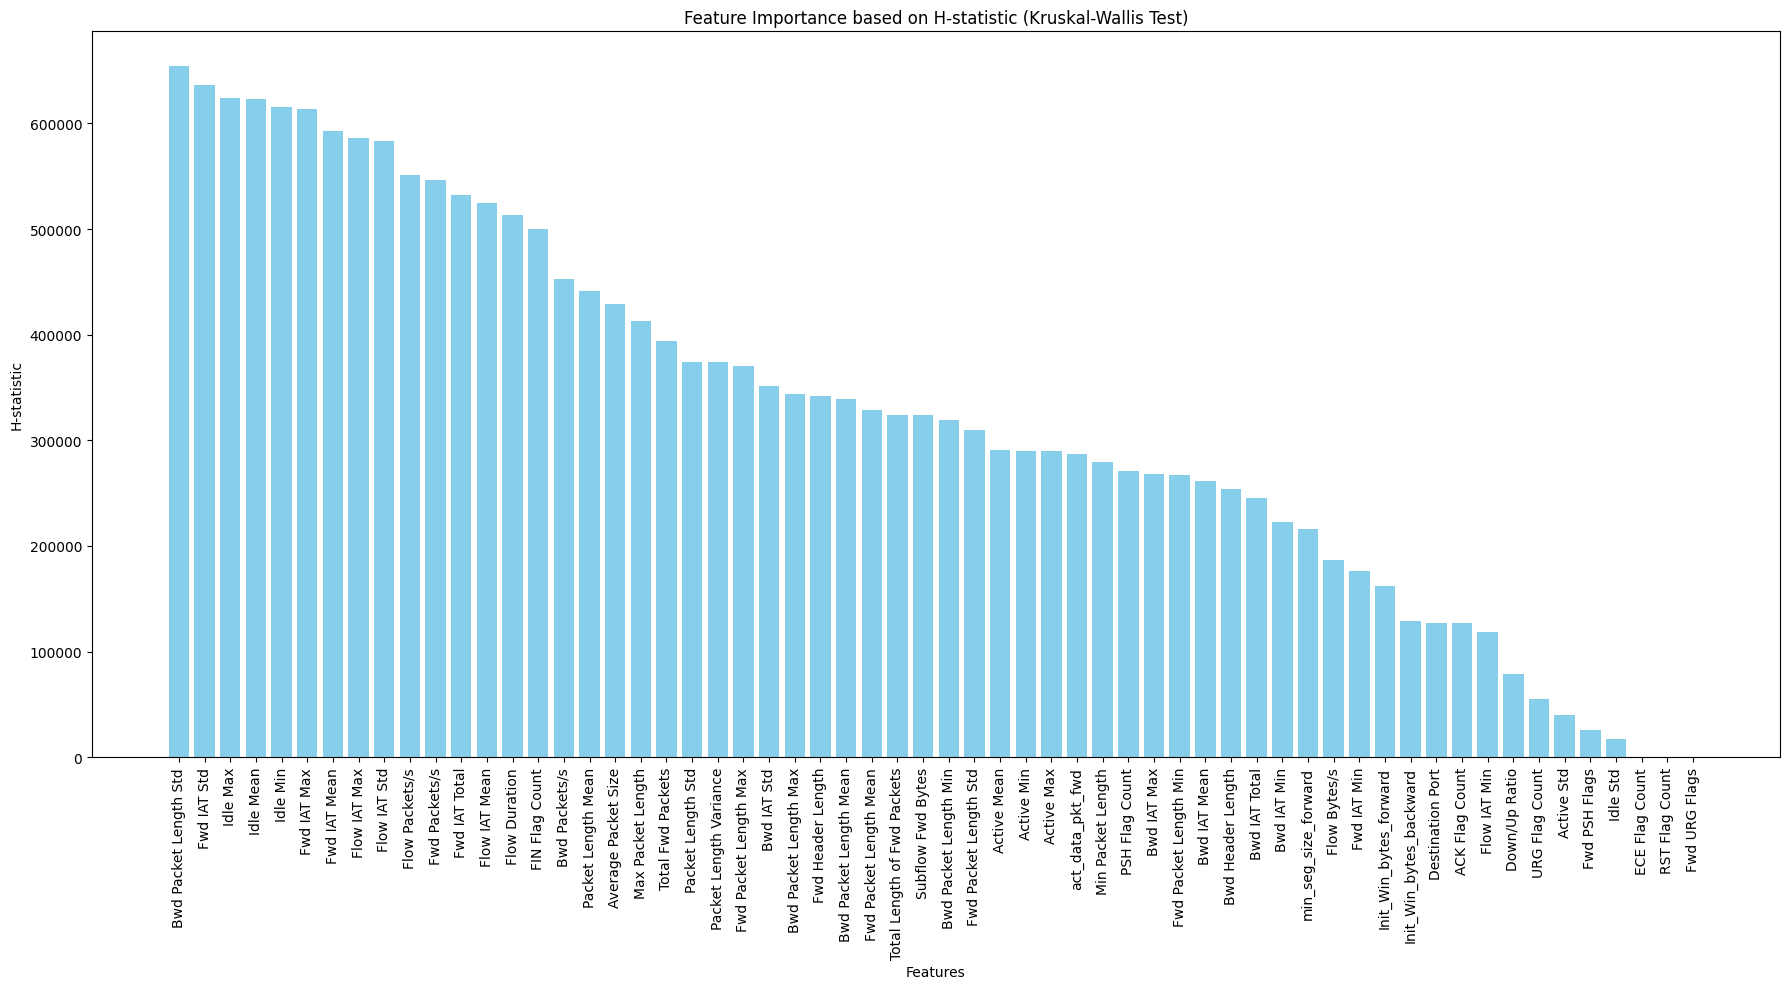

In [48]:
h_p_stats = analyze_feature_importance(data, num_feat)

Cross-Validation Score: 0.9987 ± 0.0001

Classification Report:

                precision    recall  f1-score   support

          Bots       0.86      0.47      0.61       584
   Brute Force       1.00      1.00      1.00      2745
          DDoS       1.00      1.00      1.00     38404
           DoS       1.00      1.00      1.00     58124
Normal Traffic       1.00      1.00      1.00    628518
 Port Scanning       0.99      1.00      0.99     27208
   Web Attacks       0.99      0.97      0.98       643

      accuracy                           1.00    756226
     macro avg       0.98      0.92      0.94    756226
  weighted avg       1.00      1.00      1.00    756226




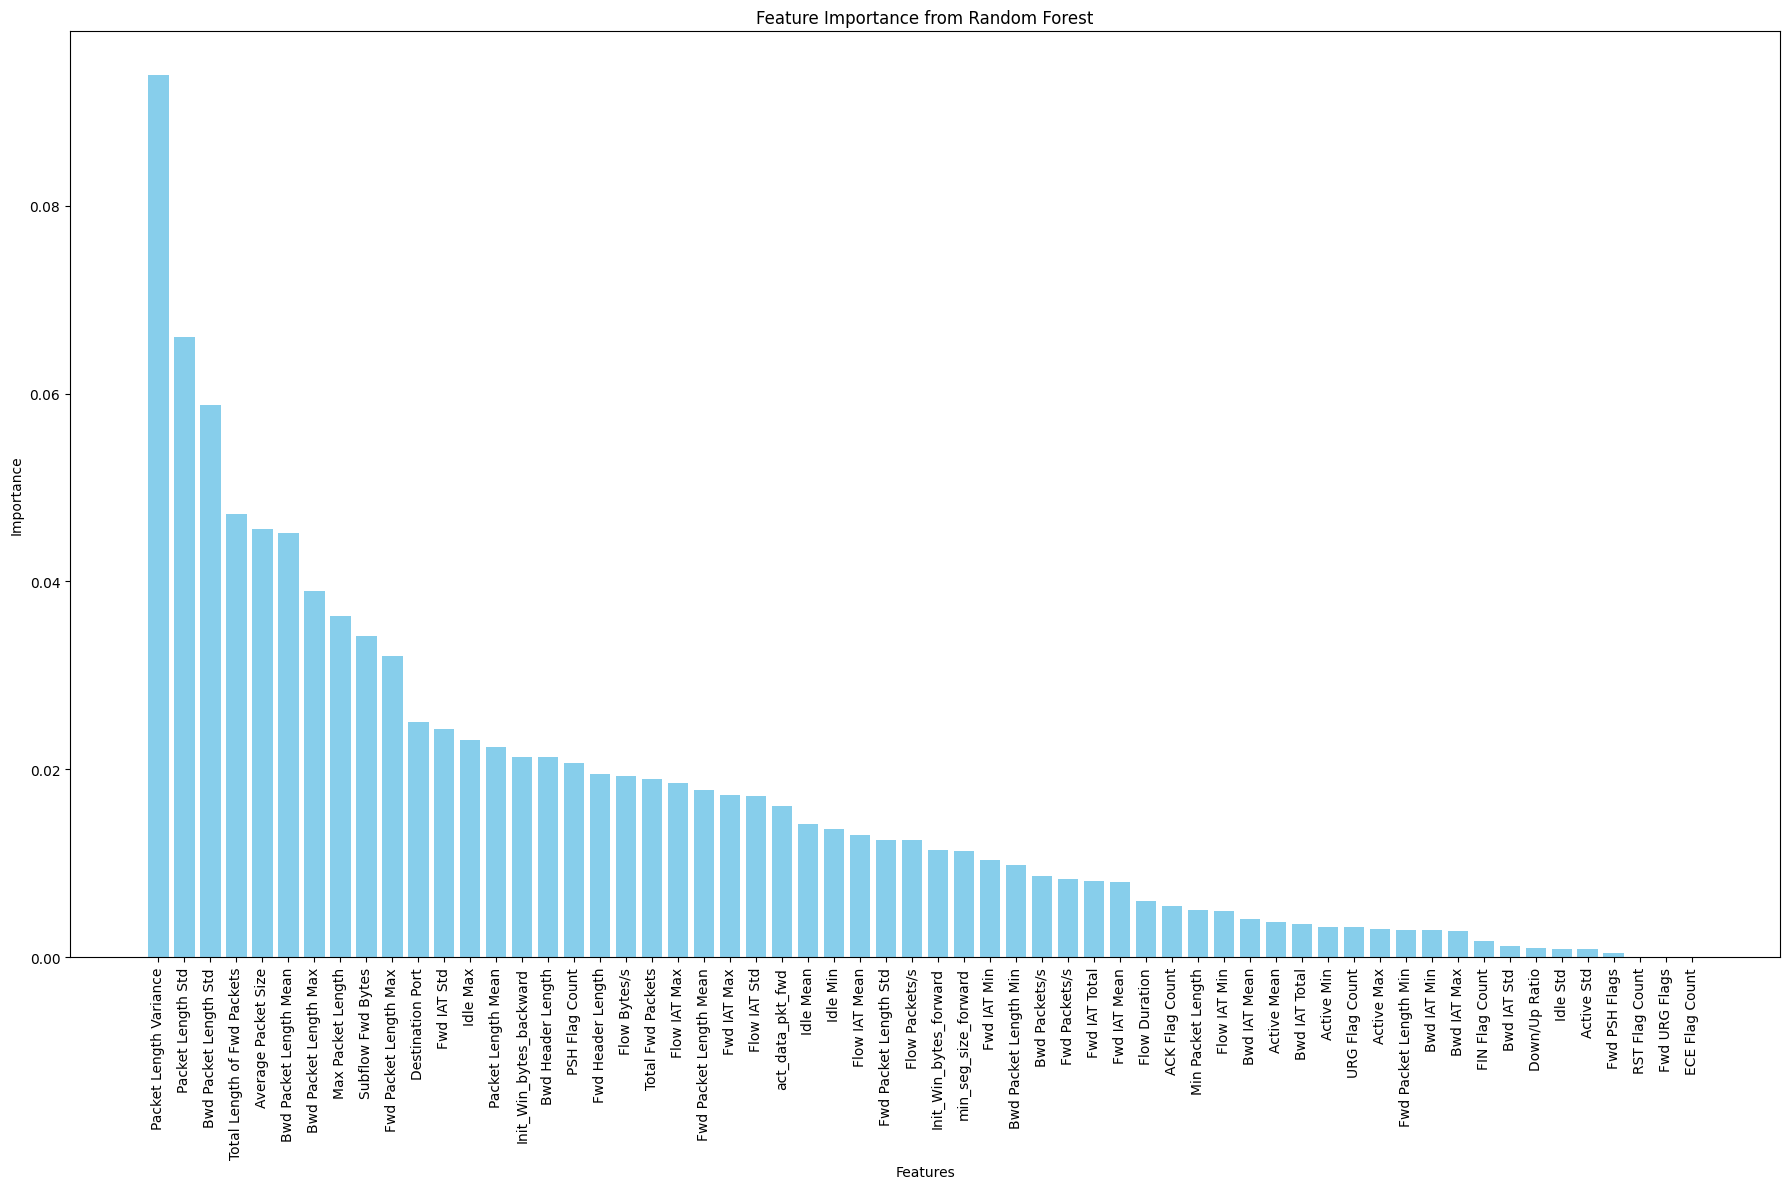

In [49]:
feature_importance_tree, cm, rf_labels, cv_scores = analyze_feature_importance_rf(data, num_feat)

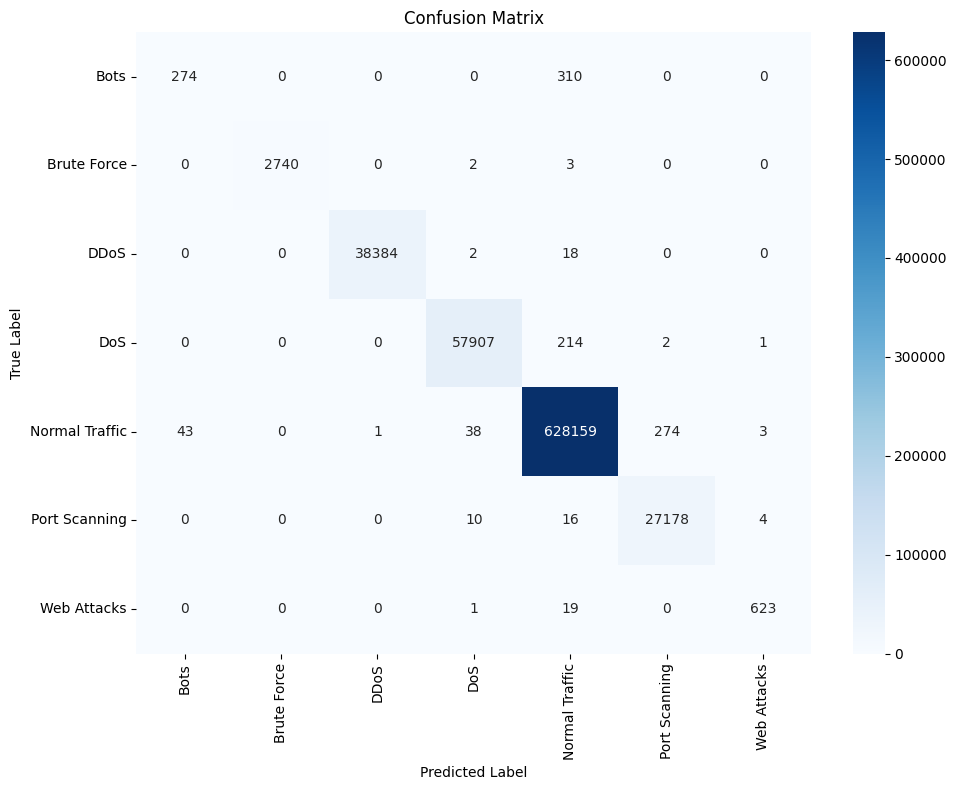

In [50]:

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_labels, yticklabels=rf_labels)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

"Sau khi đánh giá hiệu năng của mô hình Random Forest, chúng tôi ghi nhận kết quả tổng thể khả quan, cho thấy sự phù hợp của mô hình này đối với việc phân tích tầm quan trọng của các đặc trưng. Tuy nhiên, ma trận nhầm lẫn (confusion matrix) và báo cáo phân loại (classification report) đã bộc lộ một điểm yếu đáng chú ý trong việc phân loại các cuộc tấn công Bot, với khoảng 1/4 số trường hợp này bị phân loại sai thành lưu lượng bình thường (điều này không quá ngạc nhiên, xét đến việc đây là lớp dữ liệu thiểu số).

Sự phân loại sai này chỉ ra một khía cạnh tiềm năng cần cải thiện trong mô hình phát hiện xâm nhập hoàn chỉnh của chúng tôi; vấn đề này có thể được giải quyết bằng cách xem xét các phương pháp phát hiện bot nâng cao hơn, kỹ thuật đặc trưng chuyên biệt (specialized feature engineering), cũng như các kỹ thuật cân bằng dữ liệu. Bất chấp hạn chế này, hiệu năng tổng thể vẫn đảm bảo tính hợp lý khi sử dụng các điểm số quan trọng của đặc trưng từ Random Forest như một tham chiếu giá trị để so sánh với thống kê H của kiểm định Kruskal-Wallis trong quy trình chọn lọc đặc trưng tiếp theo."

In [51]:
h_p_stats = h_p_stats.reset_index()
h_p_stats = h_p_stats.rename(columns={'index': 'Feature'})


comp_tb = feature_importance_tree.merge(h_p_stats, on='Feature', how='left')
comp_tb_sorted = comp_tb.sort_values(by='Importance', ascending=False)
comp_tb_sorted

,Feature,Importance,H-statistic,p-value
0,Packet Length Variance,9.387163e-02,373845.434316,0.000000e+00
1,Packet Length Std,6.601342e-02,373896.560353,0.000000e+00
2,Bwd Packet Length Std,5.878555e-02,654400.346609,0.000000e+00
3,Total Length of Fwd Packets,4.720259e-02,324367.440051,0.000000e+00
4,Average Packet Size,4.563199e-02,429097.080675,0.000000e+00
5,Bwd Packet Length Mean,4.517260e-02,338820.640791,0.000000e+00
6,Bwd Packet Length Max,3.895501e-02,343538.176327,0.000000e+00
7,Max Packet Length,3.632995e-02,413042.599252,0.000000e+00
8,Subflow Fwd Bytes,3.424406e-02,324367.440051,0.000000e+00
9,Fwd Packet Length Max,3.202516e-02,370387.060527,0.000000e+00


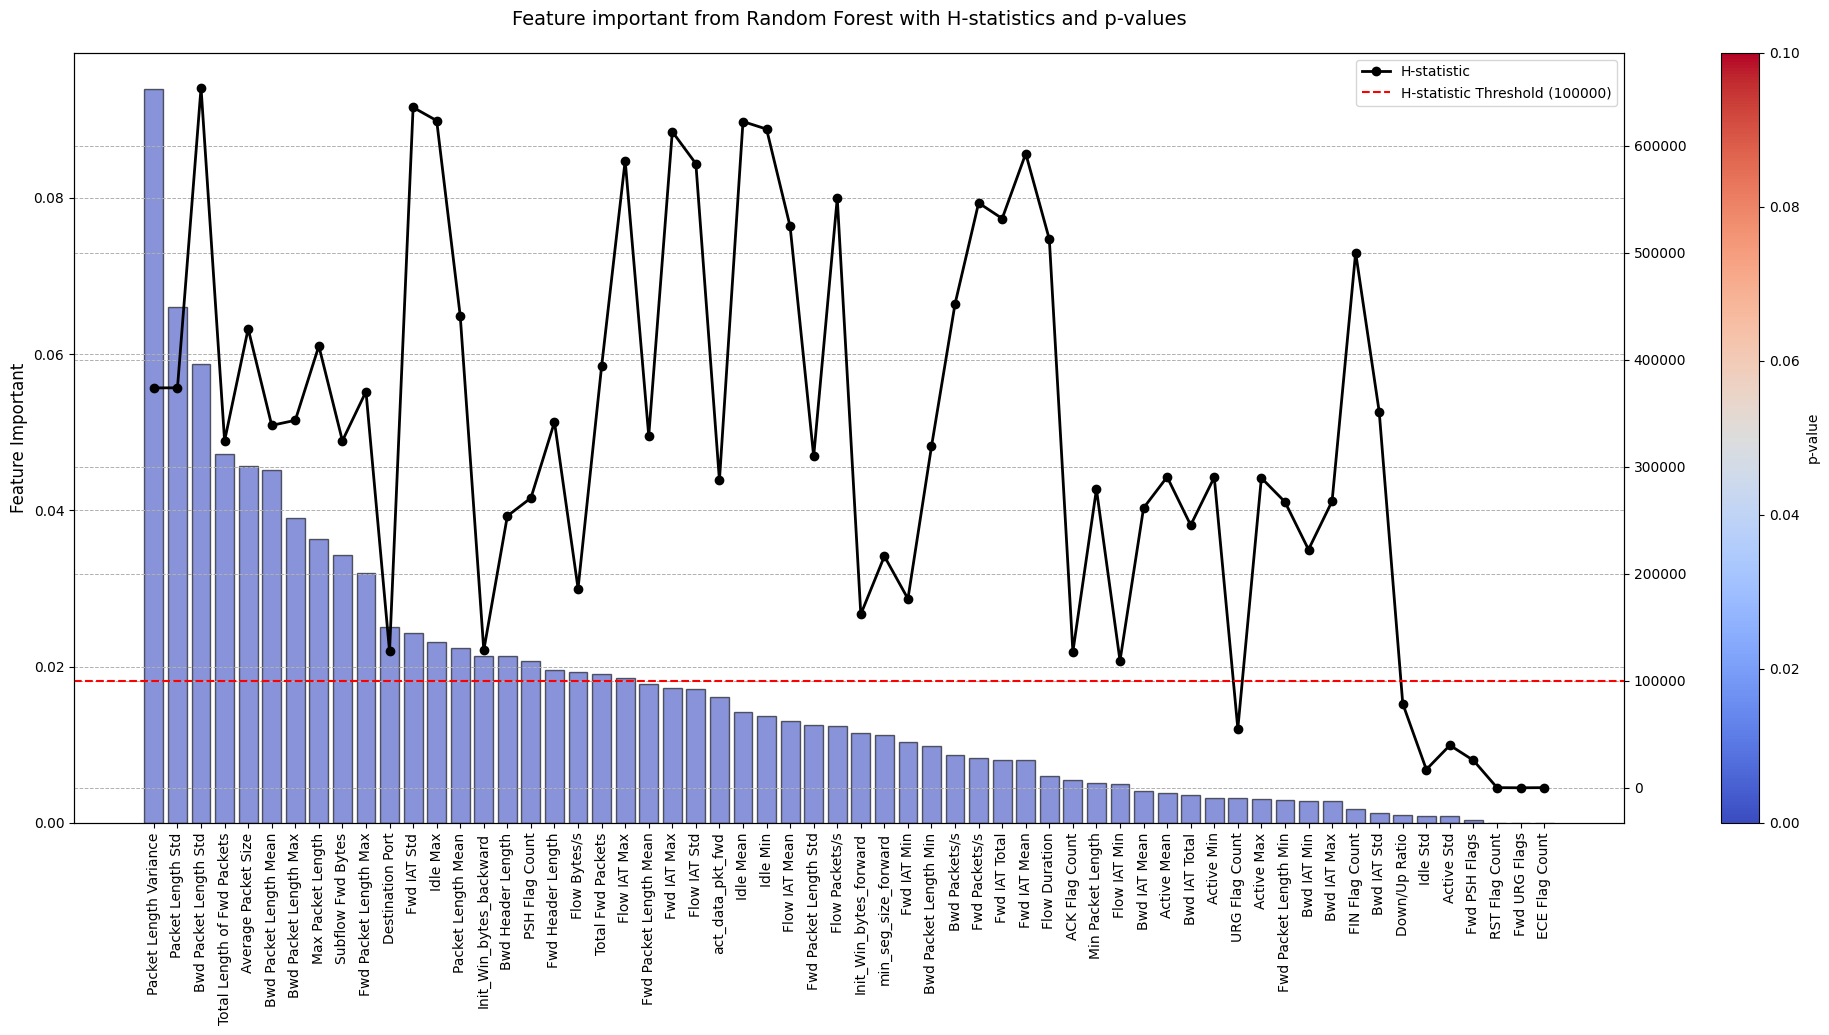

In [52]:
plt.figure(figsize=(25, 10))
colors = sns.color_palette("coolwarm", as_cmap=True)
ax1 = plt.gca()
ax2 = ax1.twinx()

p_values_norm = (comp_tb_sorted['p-value'] - comp_tb_sorted['p-value'].min()) / (0.1 - comp_tb_sorted['p-value'].min())


bars = ax1.bar(comp_tb_sorted['Feature'],
                comp_tb_sorted['Importance'],
                alpha=0.6,
                color=[colors(value) for value in p_values_norm], 
                edgecolor='black')

line = ax2.plot(comp_tb_sorted['Feature'],
                 comp_tb_sorted['H-statistic'],
                 color='black',
                 linewidth=2,
                 label='H-statistic',
                 marker='o')

threshold = 100000
ax2.axhline(y=threshold, color='red', linestyle='--', label=f'H-statistic Threshold ({threshold})')
ax2.legend()

ax1.set_ylabel('Feature Important', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax1.set_xticks(range(len(comp_tb_sorted)))
ax1.set_xticklabels(comp_tb_sorted['Feature'], rotation=90, ha='center', fontsize=10)

plt.title('Feature important from Random Forest with H-statistics and p-values',
          fontsize=14, pad=20)

sm = plt.cm.ScalarMappable(cmap=colors, norm=plt.Normalize(vmin=comp_tb_sorted['p-value'].min(), vmax=0.1))
cbar = plt.colorbar(sm, ax=ax1, orientation='vertical')
cbar.set_label('p-value', fontsize=10)

for ax in [ax1, ax2]:
    ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)

plt.show()

Kết luận biểu đồ minh họa: một số đặc trưng được mô hình Random Forest lựa chọn có chỉ số thống kê H (H-statistics) thấp hơn, thì những đặc trưng quan trọng nhất lại nằm trong phạm vi tập trung các giá trị thống kê H cao nhất. Tuy nhiên, thông tin đáng chú ý nhất lại nằm ở phía đuôi phải, nơi có sự hội tụ của các đặc trưng có mức độ ưu tiên thấp nhất và mức độ liên quan theo thống kê H gần như bằng không. Dựa trên những kết quả này, các đặc trưng ít quan trọng nhất sẽ bị loại bỏ khỏi bộ dữ liệu, điều này giúp:


1. Cải thiện hiệu quả mô hình: Việc huấn luyện với ít đặc trưng hơn sẽ làm giảm chi phí tính toán (cả về thời gian và bộ nhớ)
2. Giảm nhiễu: Loại bỏ các đặc trưng không liên quan đôi khi có thể cải thiện hiệu suất mô hình bằng cách giảm thiểu nhiễu và ngăn chặn hiện tượng quá khớp (overfitting)
3. Đơn giản hóa việc diễn giải: Các mô hình với số lượng đặc trưng ít hơn thường dễ hiểu và giải thích hơn.


In [53]:

cols_to_remove = ['ECE Flag Count', 'RST Flag Count', 'Fwd URG Flags', 'Idle Std', 'Fwd PSH Flags', 'Active Std', 'Down/Up Ratio', 'URG Flag Count']
data.drop(columns=cols_to_remove, inplace=True)

In [54]:
print("\n" + "="*70)
print("Top 20 feature most important (Random Forest)")
print("="*70)
for idx, (_, row) in enumerate(feature_importance_tree.head(20).iterrows(), 1):
    print(f"{idx:2d}. {row['Feature']:40s} | Importance: {row['Importance']:.6f}")
print("="*70 + "\n")


Top 20 feature most important (Random Forest)
 1. Packet Length Variance                   | Importance: 0.093872
 2. Packet Length Std                        | Importance: 0.066013
 3. Bwd Packet Length Std                    | Importance: 0.058786
 4. Total Length of Fwd Packets              | Importance: 0.047203
 5. Average Packet Size                      | Importance: 0.045632
 6. Bwd Packet Length Mean                   | Importance: 0.045173
 7. Bwd Packet Length Max                    | Importance: 0.038955
 8. Max Packet Length                        | Importance: 0.036330
 9. Subflow Fwd Bytes                        | Importance: 0.034244
10. Fwd Packet Length Max                    | Importance: 0.032025
11. Destination Port                         | Importance: 0.025031
12. Fwd IAT Std                              | Importance: 0.024341
13. Idle Max                                 | Importance: 0.023115
14. Packet Length Mean                       | Importance: 0.022399
1

## 5.1. Tổng quan các feature cuối cùng để huấn luyệnn

| **Column Name**                    | **Description**                                                                                                                                             |
|-------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Destination Port                    | Cổng đích của luồng dữ liệu (flow).                                                                                                                         |
| Flow Duration                       | Thời lượng của luồng dữ liệu.                                                                                                                                   |
| Total Fwd Packets                   | Tổng số lượng gói tin chiều đi (forward) trong luồng                                                                                                      |
| Total Length of Fwd Packets         | Tổng độ dài của các gói tin chiều đi trong luồng                                                                                                         |
| Fwd Packet Length Max               | Kích thước lớn nhất của gói tin chiều đi                                                                                                                    |
| Fwd Packet Length Min               | The minimum size of forwarded packets.                                                                                                                     |
| Fwd Packet Length Mean              | The average length of forwarded packets in the flow.                                                                                                       |
| Fwd Packet Length Std               | The standard deviation of forwarded packet lengths in the flow.                                                                                           |
| Bwd Packet Length Max               | The maximum size of backward packets.                                                                                                                       |
| Bwd Packet Length Min               | The minimum size of backward packets.                                                                                                                     |
| Bwd Packet Length Mean              | The average size of backward packets.                                                                                                                       |
| Bwd Packet Length Std               | The standard deviation of backward packet lengths in the flow.                                                                                             |
| Flow Bytes/s                        | The number of bytes transferred per second in the flow.                                                                                                   |
| Flow Packets/s                      | The number of packets transferred per second in the flow.                                                                                                  |
| Flow IAT Mean                       | The average inter-arrival time of packets in the flow.                                                                                                     |
| Flow IAT Std                        | The standard deviation of the inter-arrival times of packets in the flow.                                                                                  |
| Flow IAT Max                        | The maximum inter-arrival time of packets in the flow.                                                                                                      |
| Flow IAT Min                        | The minimum inter-arrival time of packets in the flow.                                                                                                     |
| Fwd IAT Total                       | The total forward inter-arrival time observed during the flow.                                                                                             |
| Fwd IAT Mean                        | The mean forward inter-arrival time observed during the flow.                                                                                              |
| Fwd IAT Std                         | The standard deviation of the forward inter-arrival time during the flow.                                                                                 |
| Fwd IAT Max                         | The maximum forward inter-arrival time observed during the flow.                                                                                           |
| Fwd IAT Min                         | The minimum forward inter-arrival time observed during the flow.                                                                                           |
| Bwd IAT Total                       | The total backward inter-arrival time during the flow.                                                                                                    |
| Bwd IAT Mean                        | The average backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Std                         | The standard deviation of the backward inter-arrival time during the flow.                                                                                 |
| Bwd IAT Max                         | The maximum backward inter-arrival time during the flow.                                                                                                  |
| Bwd IAT Min                         | The minimum backward inter-arrival time during the flow.                                                                                                  |
| Fwd Header Length                   | The total length of the header in forwarded packets.                                                                                                       |
| Bwd Header Length                   | The total length of the header in backward packets.                                                                                                        |
| Fwd Packets/s                       | The number of forwarded packets transferred per second in the flow.                                                                                        |
| Bwd Packets/s                       | The number of backward packets transferred per second in the flow.                                                                                        |
| Min Packet Length                   | The minimum packet length observed in the flow.                                                                                                            |
| Max Packet Length                   | The maximum packet length observed in the flow.                                                                                                            |
| Packet Length Mean                  | The average packet length in the flow.                                                                                                                     |
| Packet Length Std                   | The standard deviation of packet lengths in the flow.                                                                                                      |
| Packet Length Variance              | The variance of packet lengths in the flow.                                                                                                                |
| FIN Flag Count                      | The number of FIN flags observed in the flow.                                                                                                               |
| PSH Flag Count                      | The number of PSH flags observed in the flow.                                                                                                               |
| ACK Flag Count                      | The number of ACK flags observed in the flow.                                                                                                               |
| Average Packet Size                 | The average size of the packets in the flow.                                                                                                               |
| Subflow Fwd Bytes                   | The number of bytes in the forwarded subflow.                                                                                                              |
| Init_Win_bytes_forward              | The initial window size in bytes in the forward direction.                                                                                                 |
| Init_Win_bytes_backward             | The initial window size in bytes in the backward direction.                                                                                                |
| act_data_pkt_fwd                    | The number of active data packets forwarded.                                                                                                               |
| min_seg_size_forward                | The minimum segment size forwarded in the flow.                                                                                                            |
| Active Mean                         | The average amount of activity observed during the flow.                                                                                                   |
| Active Max                          | The maximum amount of activity observed during the flow.                                                                                                   |
| Active Min                          | The minimum amount of activity observed during the flow.                                                                                                   |
| Idle Mean                           | The average idle time observed during the flow.                                                                                                            |
| Idle Max                            | The maximum idle time observed during the flow.                                                                                                            |
| Idle Min                            | The minimum idle time observed during the flow.                                                                                                            |
| Attack Type                         | The target class, indicating the type of attack or normal traffic.                                                                                        |


# 6. Outputs

Lưu ý về các kỹ thuật lấy mẫu và chuẩn hóa:
Việc áp dụng các kỹ thuật tái lấy mẫu và/hoặc chuẩn hóa, chẳng hạn như SMOTE và RobustScaler, trên toàn bộ tập dữ liệu sẽ vi phạm nguyên tắc giữ cho tập kiểm tra (test set) hoàn toàn chưa được nhìn thấy trong quá trình huấn luyện mô hình. Điều này có thể dẫn đến các chỉ số hiệu năng lạc quan quá mức, vì mô hình có thể gián tiếp tiếp nhận thông tin từ tập test trong lúc huấn luyện.

Dựa trên phân tích được thực hiện trong notebook này, cả hai kỹ thuật đều cho thấy lợi ích khi huấn luyện mô hình. Tuy nhiên, các phương pháp này chỉ sẽ được triển khai trong notebook tiếp theo, tại đó tập dữ liệu sẽ được chia thành tập huấn luyện và tập kiểm tra, với trọng tâm là huấn luyện và so sánh các mô hình học máy.

In [55]:
data.to_csv('cicids2017_cleaned.csv', index=False)

# Tham khảo

Tham khảo từ nguồn 
S. Lai, T. Xue, H. Xiao, L. Hu, J. Wu, N. Feng, R. Guan, H.
Liao, Z. Li, and Y. Yue, “Drive: Dependable Robust Interpretable
Visionary Ensemble Framework in Autonomous Driving,” arXiv preprint
arXiv:2409.10330, 2024. [Online]. Available:
N. Moustafa and J. Slay, “The evaluation of network anomaly detection
systems: Statistical analysis of the UNSW-NB15 data set and the
comparison with the KDD99 data set,” Information Security Journal:
A Global Perspective, vol. 25, no. 1-3, pp. 18–31, 2016. [Online].
Available: https://doi.org/10.1080/19393555.2015.1125974.
[3] R. Sommer and V. Paxson, “Outside the closed world: On using machine
learning for network intrusion detection,” in Proceedings of the IEEE
Symposium on Security and Privacy, 2010, pp. 305–316.
[4] V. Chandola, A. Banerjee, and V. Kumar, “Anomaly detection: A survey,”
ACM Computing Surveys, vol. 41, no. 3, p. Article 15, 2009. [Online].
Available: https://doi.org/10.1145/1541880.1541882.
[5] T. Elmasri, N. Samir, M. Mashaly, and Y. Atef, “Evaluation of CICIDS2017 with qualitative comparison of machine learning algorithm,”
in 2020 IEEE Cloud Summit, 2020, pp. 46–51